In [2]:
import os
import tensorflow as tf
from tensorflow.keras import backend as K

# Reduce TF logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Clear previous graphs
K.clear_session()

In [3]:
print("Dataset folders ready!")

Dataset folders ready!


In [4]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("TensorFlow:", tf.__version__)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9
TensorFlow: 2.10.1


In [5]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
c:\Users\Shrinivas\Desktop\MLB_VQA


In [11]:
import os
import json
import pandas as pd

# ============================================================
# Base Folder
# ============================================================

BASE_DIR = "kvasir"

TRAIN_JSON = os.path.join(BASE_DIR, "train.jsonl")
VAL_JSON   = os.path.join(BASE_DIR, "val.jsonl")

IMG_DIR = os.path.join(BASE_DIR, "images")


# ============================================================
# JSON Loader
# ============================================================

def load_kvasir_json(json_file):

    data = []

    with open(json_file, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)

            image_path = os.path.join(BASE_DIR, item["image"])
            question   = item["question"]
            answer     = item["answer"]

            data.append([image_path, question, answer])

    df = pd.DataFrame(data, columns=["image_path", "question", "answer"])

    return df


# ============================================================
# Load Train + Val
# ============================================================

train_df = load_kvasir_json(TRAIN_JSON)
val_df   = load_kvasir_json(VAL_JSON)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("Sample row:")
print(train_df.head())

Train size: 32365
Val size: 11768
Sample row:
                image_path                                           question  \
0  kvasir\images/18177.jpg               Is there a green/black box artefact?   
1  kvasir\images/20270.jpg  Are there any abnormalities in the image? Chec...   
2  kvasir\images/51123.jpg    What type of procedure is the image taken from?   
3  kvasir\images/26772.jpg                      Have all polyps been removed?   
4   kvasir\images/6613.jpg                     What is the size of the polyp?   

        answer  
0          yes  
1        polyp  
2  colonoscopy  
3           no  
4         none  


In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["question"] = train_df["question"].apply(clean_text)
val_df["question"] = val_df["question"].apply(clean_text)

train_df["answer"] = train_df["answer"].apply(
    lambda x: "sostok " + clean_text(x) + " eostok"
)

val_df["answer"] = val_df["answer"].apply(
    lambda x: "sostok " + clean_text(x) + " eostok"
)

In [13]:
max_q_len = 20
max_a_len = 15

# Question tokenizer
x_tokenizer = Tokenizer(oov_token="<OOV>")
x_tokenizer.fit_on_texts(train_df["question"])

x_train_pad = pad_sequences(
    x_tokenizer.texts_to_sequences(train_df["question"]),
    maxlen=max_q_len,
    padding='post'
)

x_val_pad = pad_sequences(
    x_tokenizer.texts_to_sequences(val_df["question"]),
    maxlen=max_q_len,
    padding='post'
)

x_vocab = len(x_tokenizer.word_index) + 1

# Answer tokenizer
y_tokenizer = Tokenizer(oov_token="<OOV>")
y_tokenizer.fit_on_texts(train_df["answer"])

y_train_pad = pad_sequences(
    y_tokenizer.texts_to_sequences(train_df["answer"]),
    maxlen=max_a_len,
    padding='post'
)

y_val_pad = pad_sequences(
    y_tokenizer.texts_to_sequences(val_df["answer"]),
    maxlen=max_a_len,
    padding='post'
)

y_vocab = len(y_tokenizer.word_index) + 1

print("Question vocab:", x_vocab)
print("Answer vocab:", y_vocab)

Question vocab: 58
Answer vocab: 65


In [14]:
def load_image(path):
    img = tf.keras.preprocessing.image.load_img(path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img

In [18]:
def create_dataset(x, y, image_paths, batch_size=8, training=True):

    def generator():
        for i in range(len(x)):
            img = load_image(image_paths[i])
            decoder_input = y[i][:-1]
            decoder_target = y[i][1:]
            yield (x[i], img, decoder_input), decoder_target

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (
                tf.TensorSpec((max_q_len,), tf.int32),
                tf.TensorSpec((224,224,3), tf.float32),
                tf.TensorSpec((max_a_len-1,), tf.int32),
            ),
            tf.TensorSpec((max_a_len-1,), tf.int32)
        )
    )

    if training:
        dataset = dataset.shuffle(1024).repeat()

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    x_train_pad,
    y_train_pad,
    train_df["image_path"].values,
    batch_size=8,
    training=True
)

val_dataset = create_dataset(
    x_val_pad,
    y_val_pad,
    val_df["image_path"].values,
    batch_size=8,
    training=False
)

In [19]:
# -------- Image Backbone --------
cnn = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

cnn.trainable = False
for layer in cnn.layers[-20:]:
    layer.trainable = True

img_input = cnn.input
features = cnn.get_layer("conv5_block3_out").output
features = Reshape((49, 2048))(features)
features = Dense(1024, activation='relu')(features)


# -------- Question Encoder --------
q_input = Input(shape=(max_q_len,))
q_embed = Embedding(x_vocab, 100, mask_zero=True)(q_input)

q_out, q_h, q_c = LSTM(
    1024,
    return_sequences=True,
    return_state=True
)(q_embed)


# -------- MLB Attention --------
class MLB_Attention(tf.keras.layers.Layer):
    def __init__(self, joint_dim=512, **kwargs):
        super(MLB_Attention, self).__init__(**kwargs)
        self.joint_dim = joint_dim

    def build(self, input_shape):
        self.Wv = Dense(self.joint_dim, use_bias=False)
        self.Wq = Dense(self.joint_dim, use_bias=False)
        self.score = Dense(1, use_bias=False)
        super(MLB_Attention, self).build(input_shape)

    def call(self, inputs):
        v, q = inputs
        q = tf.expand_dims(q, 1)
        joint = tf.nn.tanh(self.Wv(v) * self.Wq(q))
        weights = tf.nn.softmax(self.score(joint), axis=1)
        return tf.reduce_sum(weights * v, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"joint_dim": self.joint_dim})
        return config


# -------- Sequential Attention --------

# First attention
attention1 = MLB_Attention(512)
context1 = attention1([features, q_h])

# Combine first context with question representation
refined_query = Concatenate()([context1, q_h])
refined_query = Dense(1024, activation='tanh')(refined_query)

# Second attention using refined query
attention2 = MLB_Attention(512)
context2 = attention2([features, refined_query])


# Final context
context = Dense(1024, activation='relu')(context2)


# -------- Decoder Initialization --------
decoder_init = Concatenate()([context, q_h])
decoder_init = Dense(1024, activation='tanh')(decoder_init)


# -------- Decoder --------
dec_input = Input(shape=(None,))

dec_embed = Embedding(y_vocab, 256, mask_zero=True)(dec_input)

dec_out, _, _ = LSTM(
    1024,
    return_sequences=True,
    return_state=True,
    dropout=0.3,
    recurrent_dropout=0.3
)(dec_embed, initial_state=[decoder_init, decoder_init])


# -------- Output Layer --------
output = TimeDistributed(
    Dense(y_vocab, activation='softmax', dtype='float32')
)(dec_out)


# -------- Final Model --------
model = Model([q_input, img_input, dec_input], output)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Use standard sparse categorical crossentropy (compatible with all TF versions)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

steps_per_epoch = len(train_df) // 8
val_steps = len(val_df) // 8

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_imageclef_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/100
4045/4045 [==============================] - 893s 211ms/step - loss: 0.1174 - accuracy: 0.8710 - val_loss: 0.0560 - val_accuracy: 0.9321 - lr: 1.0000e-04
Epoch 2/100
4045/4045 [==============================] - 519s 128ms/step - loss: 0.0492 - accuracy: 0.9372 - val_loss: 0.0474 - val_accuracy: 0.9411 - lr: 1.0000e-04
Epoch 3/100
4045/4045 [==============================] - 492s 122ms/step - loss: 0.0425 - accuracy: 0.9443 - val_loss: 0.0429 - val_accuracy: 0.9450 - lr: 1.0000e-04
Epoch 4/100
4045/4045 [==============================] - 488s 121ms/step - loss: 0.0391 - accuracy: 0.9482 - val_loss: 0.0407 - val_accuracy: 0.9480 - lr: 1.0000e-04
Epoch 5/100
4045/4045 [==============================] - 523s 129ms/step - loss: 0.0365 - accuracy: 0.9510 - val_loss: 0.0400 - val_accuracy: 0.9489 - lr: 1.0000e-04
Epoch 6/100
4045/4045 [==============================] - 540s 133ms/step - loss: 0.0335 - accuracy: 0.9552 - val_loss: 0.0402 - val_accuracy: 0.9485 - lr: 1.0000e-04
Epoc

In [20]:
# -------- Feature Extractor Model --------

feature_extractor = Model(
    inputs=model.input[1], 
    outputs=model.get_layer("reshape").output
)

In [ ]:
feature_cache = {}

for img_path in tqdm(val_df["image_path"].values):

    img = load_image(img_path)
    img = np.expand_dims(img, axis=0)

    features = feature_extractor.predict(img, verbose=0)

    feature_cache[img_path] = features

  3%|▎         | 318/11768 [00:38<23:23,  8.16it/s] 


KeyboardInterrupt: 

In [ ]:
reverse_target_word_index = y_tokenizer.index_word
target_word_index = y_tokenizer.word_index


def decode_sequence_cached(input_seq, image_path, beam_width=3):

    img_features = feature_cache[image_path]

    start_token = target_word_index['sostok']
    end_token = target_word_index['eostok']

    sequences = [[[start_token], 0.0]]

    for _ in range(max_a_len):

        all_candidates = []

        for seq, score in sequences:

            if seq[-1] == end_token:
                all_candidates.append((seq, score))
                continue

            target_seq = np.array([seq])

            preds = model.predict(
                [input_seq, img_features, target_seq],
                verbose=0
            )

            probs = preds[0, -1, :]

            top_indices = np.argsort(probs)[-beam_width:]

            for idx in top_indices:

                candidate = seq + [idx]

                candidate_score = score - np.log(probs[idx] + 1e-10)

                all_candidates.append((candidate, candidate_score))

        ordered = sorted(all_candidates, key=lambda tup: tup[1])

        sequences = ordered[:beam_width]

    best_seq = sequences[0][0]

    decoded = []

    for idx in best_seq:

        word = reverse_target_word_index.get(idx, "")

        if word == 'eostok':
            break

        if word != 'sostok':
            decoded.append(word)

    return " ".join(decoded)

NameError: name 'y_tokenizer' is not defined

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

reverse_target_word_index = y_tokenizer.index_word
target_word_index = y_tokenizer.word_index


def evaluate_validation(show_samples=5):

    smoothie = SmoothingFunction().method4

    total_bleu = 0
    total_tokens = 0
    correct_tokens = 0

    print("Running validation evaluation...\n")

    for i in tqdm(range(len(x_val_pad))):

        image_path = val_df["image_path"].iloc[i]

        # ---- Prediction (using cached CNN features) ----
        pred = decode_sequence_cached(
            x_val_pad[i].reshape(1, max_q_len),
            image_path
        )

        # ---- Ground Truth ----
        true = val_df["answer"].iloc[i]
        true = true.replace("sostok ", "").replace(" eostok", "")

        question = val_df["question"].iloc[i]

        # ---- Token Accuracy ----
        pred_tokens = pred.split()
        true_tokens = true.split()

        min_len = min(len(pred_tokens), len(true_tokens))

        for j in range(min_len):

            if pred_tokens[j] == true_tokens[j]:
                correct_tokens += 1

            total_tokens += 1

        # ---- BLEU Score ----
        if len(pred_tokens) > 0:

            total_bleu += sentence_bleu(
                [true_tokens],
                pred_tokens,
                smoothing_function=smoothie
            )

        # ---- Show Sample Predictions ----
        if i < show_samples:

            img = mpimg.imread(image_path)

            plt.figure(figsize=(12,4))

            plt.subplot(1,2,1)
            plt.imshow(img)
            plt.axis("off")

            plt.subplot(1,2,2)
            plt.text(
                0.5,0.5,
                f"Question:\n{question}\n\n"
                f"Actual:\n{true}\n\n"
                f"Predicted:\n{pred}",
                horizontalalignment='center',
                verticalalignment='center',
                wrap=True
            )
            plt.axis("off")

            plt.show()

            print("-"*50)

    # ---- Final Metrics ----
    token_accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0
    bleu_score = total_bleu / len(x_val_pad)

    print("\n====================================")
    print("Validation Token Accuracy:", round(token_accuracy,4))
    print("Validation BLEU Score:", round(bleu_score,4))
    print("====================================")

Running validation evaluation...



  0%|          | 0/11768 [00:00<?, ?it/s]

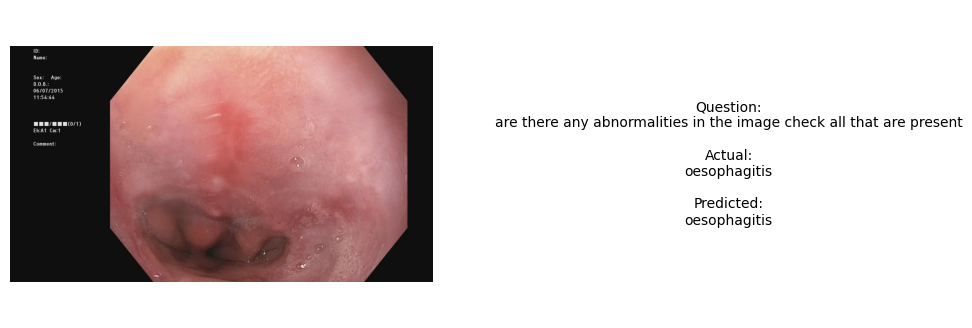

  0%|          | 1/11768 [00:07<22:56:10,  7.02s/it]

--------------------------------------------------


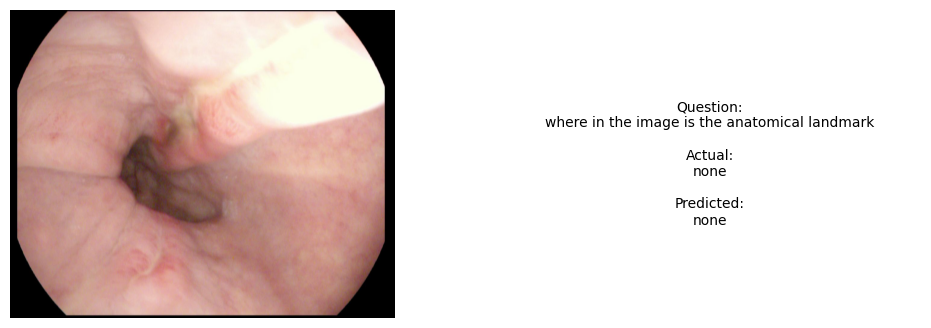

  0%|          | 2/11768 [00:24<42:57:27, 13.14s/it]

--------------------------------------------------


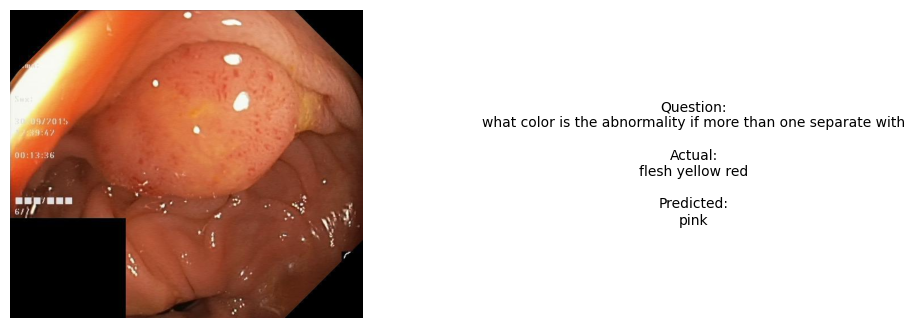

  0%|          | 3/11768 [00:29<30:11:18,  9.24s/it]

--------------------------------------------------


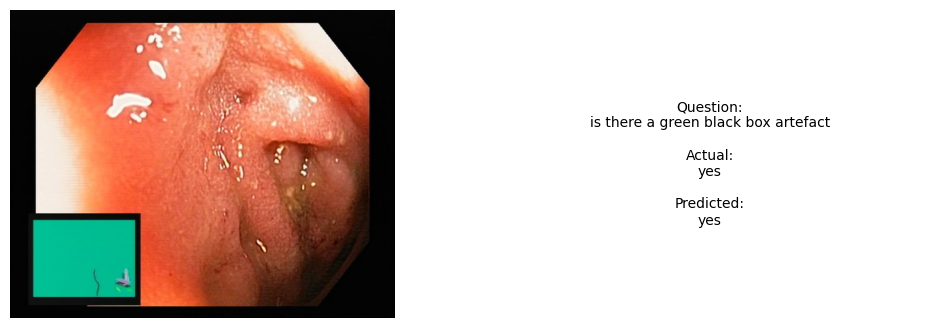

  0%|          | 4/11768 [00:32<22:55:19,  7.01s/it]

--------------------------------------------------


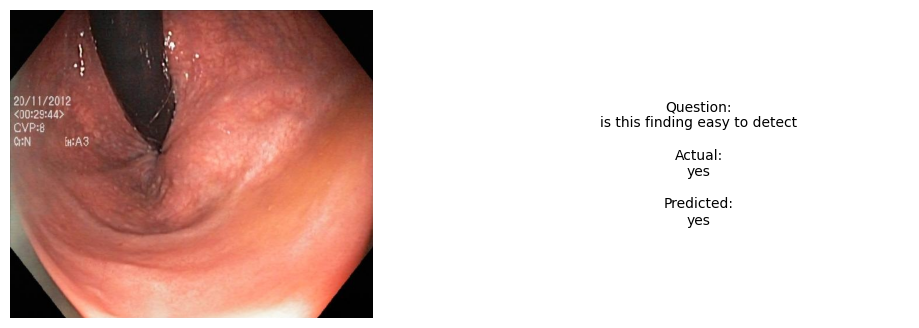

  0%|          | 5/11768 [00:36<18:59:39,  5.81s/it]

--------------------------------------------------


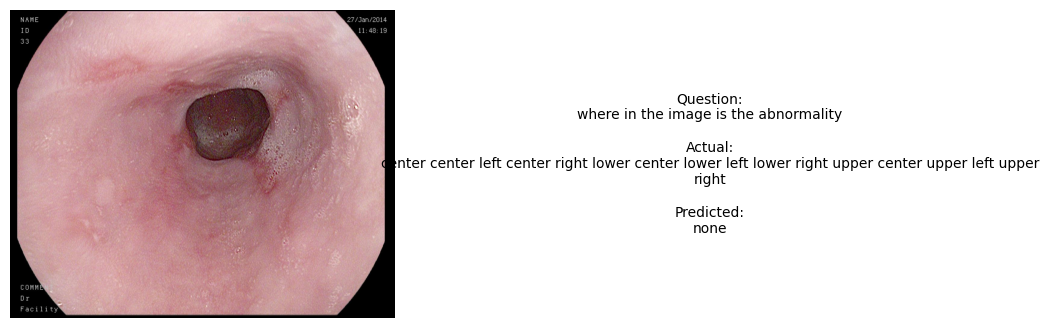

  0%|          | 6/11768 [00:50<28:28:47,  8.72s/it]

--------------------------------------------------


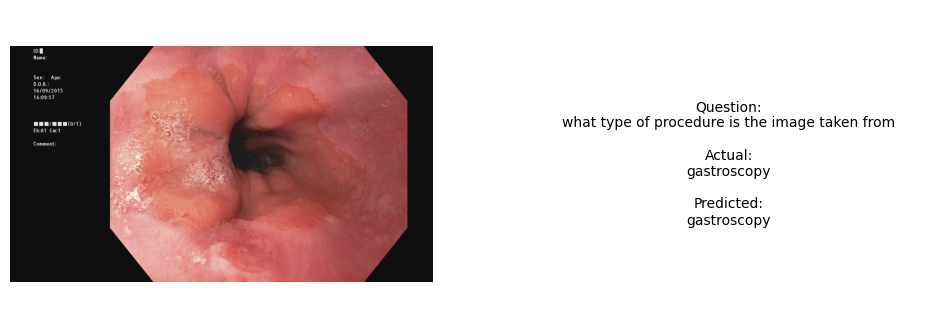

  0%|          | 7/11768 [00:54<23:30:46,  7.20s/it]

--------------------------------------------------


  0%|          | 13/11768 [01:29<22:26:48,  6.87s/it]


KeyboardInterrupt: 

In [18]:
evaluate_validation(show_samples=7)

# accuracy on testing data

In [22]:
def load_test_qa_file(filepath, image_dir):

    data = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:

        # Format:
        # image_id | category | question | answer
        parts = line.strip().split("|")

        if len(parts) >= 4:

            image_id = parts[0].strip()
            question = parts[2].strip()
            answer   = parts[3].strip()

            image_path = os.path.join(image_dir, image_id + ".jpg")

            data.append([image_path, question, answer])

    df = pd.DataFrame(data, columns=["image_path", "question", "answer"])

    return df

In [23]:
TEST_BASE = "VQAMed2019Test"

TEST_IMG_DIR = os.path.join(TEST_BASE, "VQAMed2019_Test_Images")

TEST_QA_FILE = os.path.join(
    TEST_BASE,
    "VQAMed2019_Test_Questions_w_Ref_Answers.txt"
)

test_df = load_test_qa_file(TEST_QA_FILE, TEST_IMG_DIR)

print("Test size:", len(test_df))
print(test_df.head())

Test size: 500
                                          image_path  \
0  VQAMed2019Test\VQAMed2019_Test_Images\synpic54...   
1  VQAMed2019Test\VQAMed2019_Test_Images\synpic48...   
2  VQAMed2019Test\VQAMed2019_Test_Images\synpic50...   
3  VQAMed2019Test\VQAMed2019_Test_Images\synpic37...   
4  VQAMed2019Test\VQAMed2019_Test_Images\synpic31...   

                                       question                     answer  
0                       what modality is shown?       cta - ct angiography  
1              was the mri taken with contrast?                         no  
2  what type of contrast did this patient have?                         iv  
3                 what imaging method was used?  us-d - doppler ultrasound  
4                       what modality is shown?             an - angiogram  


In [24]:
test_df["question"] = test_df["question"].apply(clean_text)

test_df["answer"] = test_df["answer"].apply(
    lambda x: "sostok " + clean_text(x) + " eostok"
)

In [25]:
x_test_seq = x_tokenizer.texts_to_sequences(test_df["question"])
x_test_pad = pad_sequences(x_test_seq, maxlen=max_q_len, padding='post')

y_test_seq = y_tokenizer.texts_to_sequences(test_df["answer"])
y_test_pad = pad_sequences(y_test_seq, maxlen=max_a_len, padding='post')

img_test_paths = test_df["image_path"].tolist()

In [26]:
acc_test, bleu_test = evaluate_subset(
    x_test_pad,    y_test_pad,
    img_test_paths
)

print("\n=========== TEST RESULTS ===========\n")

print(f"Test Accuracy : {acc_test*100:.2f}%")
print(f"Test BLEU-4   : {bleu_test*100:.2f}%")

print("\n====================================")

Evaluating: 100%|██████████| 500/500 [27:02<00:00,  3.24s/sample]


=========== TEST RESULTS ===========

Test Accuracy : 53.00%
Test BLEU-4   : 47.28%

